# Gurobi Model
Build the mathematical model explicitly in Gurobi, run replenishment plan and holdout performance.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
from IPython.display import display
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT/'data'
RESULTS_DIR = PROJECT_ROOT/'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SETTINGS = json.loads((DATA_DIR/'project_settings.json').read_text(encoding='utf-8'))
conf = json.loads((DATA_DIR/'config.json').read_text(encoding='utf-8'))
params = pd.read_csv(DATA_DIR/'sku_parameters_ASSUMED.csv').set_index('sku')
train_scenarios = pd.read_csv(DATA_DIR/'train_scenarios.csv')
SKUS = tuple(sorted(params.index.tolist()))
HORIZON = int(SETTINGS['horizon'])
SERVICE_LEVEL = float(conf['service_level'])
WAREHOUSE_CAPACITY = float(conf['warehouse_capacity'])
TIME_LIMIT_SECONDS = int(SETTINGS['time_limit_seconds'])
print('Loaded saved common inputs')

Loaded saved common inputs


In [2]:
# Build a small input dictionary
I = tuple(SKUS)
T = tuple(range(HORIZON))
S = tuple(sorted(train_scenarios['scenario'].unique()))
pairs = train_scenarios[['scenario','probability']].drop_duplicates()
assert not pairs['scenario'].duplicated().any()
prob = {str(r.scenario):float(r.probability) for r in pairs.itertuples(index=False)}
D = {(str(r.sku),int(r.week),str(r.scenario)):float(r.demand)
     for r in train_scenarios.itertuples(index=False)}
expected_keys = {(i,t,s) for i in I for t in T for s in S}
assert set(D) == expected_keys, 'Missing/duplicate SKU-week-scenario combinations.'
assert len(train_scenarios) == len(expected_keys)
assert abs(sum(prob.values()) - 1.0) < 1e-9
assert all(v >= 0 for v in D.values())
EXPECTED_DEMAND = sum(prob[s] * D[i,t,s] for i in I for t in T for s in S)
ALLOWED_EXPECTED_LOSS = (1-SERVICE_LEVEL) * EXPECTED_DEMAND
print('SKUs:',len(I),', weeks:',len(T),', scenarios:',len(S))
print('Expected units requested:', int(EXPECTED_DEMAND))
print('Expected lost-unit budget at 95% aggregate fill:', int(ALLOWED_EXPECTED_LOSS))

SKUs: 6 , weeks: 6 , scenarios: 16
Expected units requested: 8745
Expected lost-unit budget at 95% aggregate fill: 437


## Mathematical Formulation

Sets: $i\in\mathcal I$ SKU, $t\in\{0,\ldots,5\}$ week, $s\in\mathcal S$ demand scenario, with probability $p_s$.

**First-stage variables:** $q_{it}\in\mathbb Z_{\ge0}$ units ordered, $y_{it}\in\{0,1\}$ ordering/setup indicator. They form one fixed six-week plan shared by all scenarios.

**Scenario-dependent variables:** $I_{its}\ge0$ end-week inventory, $L_{its}\ge0$ lost units, $W_{its}\ge0$ disposed units.

**Objective:**
$$\min\ \sum_{i,t}(c_iq_{it}+f_iy_{it})+\sum_sp_s\sum_{i,t}(h_iI_{its}+b_iL_{its}+w_iW_{its}).$$

**Constraints** (all apply to *each* relevant SKU, week, scenario):

1. **Order linking:** $q_{it}\le M_i y_{it}$, and $0\le q_{it}\le M_i$.
2. **Inventory balance:** $I_{its}=I_{i,t-1,s}+q_{it}-d_{its}+L_{its}-W_{its}$; replace $I_{i,-1,s}$ with known initial inventory at $t=0$.
3. **Lost-sales bounds:** $0\le L_{its}\le d_{its}$.
4. **End-week capacity:** $\sum_i I_{its}\le C$ for each $(t,s)$.
5. **Aggregate expected fill rate:** $\sum_sp_s\sum_{i,t}L_{its}\le (1-\alpha)\sum_sp_s\sum_{i,t}d_{its}$ with $\alpha=0.95$.

# Gurobi Implementation

In [3]:
SHOW_SOLVER_LOG = False
try:
    import gurobipy as gp
    from gurobipy import GRB
    GUROBI_AVAILABLE = True
    print('Gurobi import succeeded:', gp.gurobi.version())
except (ImportError, OSError) as exc:
    GUROBI_AVAILABLE = False
    print('Gurobi unavailable:', exc)
gurobi_plan, gurobi_stats = None, None

Gurobi import succeeded: (13, 0, 3)


### STEP A: create model and first-stage variables.

In [4]:
if GUROBI_AVAILABLE:
    try:
        g_start = time.perf_counter()
        gm = gp.Model('m5_inventory_gurobi')
        gm.Params.OutputFlag = int(SHOW_SOLVER_LOG)
        gm.Params.TimeLimit = TIME_LIMIT_SECONDS
        gm.Params.MIPGap = 0.01
        gq = {(i,t):gm.addVar(lb=0,ub=int(params.loc[i,'max_order_per_week']),
                             vtype=GRB.INTEGER,name=f'order[{i},{t}]') for i in I for t in T}
        gy = {(i,t):gm.addVar(vtype=GRB.BINARY,name=f'order_flag[{i},{t}]')
              for i in I for t in T}
        print('Created Gurobi model and first-stage order variables.')
    except gp.GurobiError as exc:
        GUROBI_AVAILABLE = False
        print('Could not initialize Gurobi :',exc)

Restricted license - for non-production use only - expires 2027-11-29
Created Gurobi model and first-stage order variables.


### STEP B: scenario-dependent variables: inventory, lost sales and disposal.

In [5]:
if GUROBI_AVAILABLE:
    ginv = {(i,t,s):gm.addVar(lb=0,name=f'inventory[{i},{t},{s}]')
            for i in I for t in T for s in S}
    glost = {(i,t,s):gm.addVar(lb=0,ub=D[i,t,s],name=f'lost[{i},{t},{s}]')
             for i in I for t in T for s in S}
    gwaste = {(i,t,s):gm.addVar(lb=0,name=f'disposal[{i},{t},{s}]')
              for i in I for t in T for s in S}
    print('Created',gm.NumVars if gm.NumVars else 2*len(I)*len(T)+3*len(I)*len(T)*len(S), 'Gurobi variables')

Created 1800 Gurobi variables


### STEP C: constructing the objective function.

In [6]:
if GUROBI_AVAILABLE:
    g_first = gp.quicksum(float(params.loc[i,'unit_order_cost'])*gq[i,t]
              +float(params.loc[i,'fixed_order_cost'])*gy[i,t] for i in I for t in T)
    g_recourse = gp.quicksum(prob[s] * (
                float(params.loc[i,'holding_cost'])*ginv[i,t,s]
               +float(params.loc[i,'stockout_penalty'])*glost[i,t,s]
               +float(params.loc[i,'waste_penalty'])*gwaste[i,t,s])
               for i in I for t in T for s in S)
    gm.setObjective(g_first + g_recourse, GRB.MINIMIZE)
    print('Set Gurobi expected-cost objective.')

Set Gurobi expected-cost objective.


### STEP D: add constraints, as stated in the formulation.

In [7]:
if GUROBI_AVAILABLE:
    for i in I:
        for t in T:
            gm.addConstr(gq[i,t] <= int(params.loc[i,'max_order_per_week'])*gy[i,t], name=f'order_link[{i},{t}]')
            for s in S:
                opening = (float(params.loc[i,'initial_inventory']) if t == 0 else ginv[i,t-1,s])
                gm.addConstr(ginv[i,t,s] == opening + gq[i,t] - D[i,t,s] + glost[i,t,s] - gwaste[i,t,s],
                             name=f'balance[{i},{t},{s}]')
    for t in T:
        for s in S:
            gm.addConstr(gp.quicksum(ginv[i,t,s] for i in I) <= WAREHOUSE_CAPACITY, name=f'warehouse[{t},{s}]')
            
    gm.addConstr(gp.quicksum(prob[s]*glost[i,t,s] for i in I for t in T for s in S) <= ALLOWED_EXPECTED_LOSS, name='expected_service')
    gm.update()
    print('Variables =', gm.NumVars, ', Constraints =', gm.NumConstrs)

Variables = 1800 , Constraints = 709


### STEP E: solve and extract results.

In [8]:
if GUROBI_AVAILABLE:
    gm.optimize()
    if gm.SolCount:
        gurobi_plan = pd.DataFrame([{'sku':i,'week':t,'order_qty':int(round(gq[i,t].X))}
                                    for i in I for t in T])
        gurobi_stats = {'solver':'Gurobi',
                        'status': 'OPTIMAL' if gm.Status == GRB.OPTIMAL else f'STATUS_{gm.Status}',
                        'variables':gm.NumVars,'constraints':gm.NumConstrs,
                        'objective':round(float(gm.ObjVal),5),'best_bound':round(float(gm.ObjBound),5),
                        'relative_gap':round(float(gm.MIPGap),5),'elapsed_sec':round(time.perf_counter()-g_start,2)
                        }
        display(gurobi_plan.head(12))
    else:
        print('Gurobi returned no feasible order plan. Status:',gm.Status)
else:
    print('Gurobi not available')

,sku,week,order_qty
0,FOODS_3_064_CA_1_validation,0,109
1,FOODS_3_064_CA_1_validation,1,226
2,FOODS_3_064_CA_1_validation,2,222
3,FOODS_3_064_CA_1_validation,3,134
4,FOODS_3_064_CA_1_validation,4,224
5,FOODS_3_064_CA_1_validation,5,171
6,FOODS_3_090_CA_1_validation,0,531
7,FOODS_3_090_CA_1_validation,1,391
8,FOODS_3_090_CA_1_validation,2,518
9,FOODS_3_090_CA_1_validation,3,311


## Save the results

In [9]:
if gurobi_plan is None or gurobi_stats is None:
    raise RuntimeError('No Gurobi plan was produced. Check solver availability, license and solve status.')
gurobi_plan.to_csv(RESULTS_DIR/'orders_gurobi.csv',index=False)
(RESULTS_DIR/'solver_gurobi.json').write_text(json.dumps(gurobi_stats,indent=2)+'\n',encoding='utf-8')
print('Saved Gurobi plan and stats to results/.')

Saved Gurobi plan and stats to results/.


## Display **complete** order schedule and per-SKU summary

In [10]:
from IPython.display import display
import matplotlib.pyplot as plt

print('Gurobi — model solution')
print('Solve status:', gurobi_stats['status'])
print('Optimized training-scenario objective (modeled cost):', round(gurobi_stats['objective'], 2))
print('MIP gap:', round(100 * gurobi_stats['relative_gap'], 3), '%')
print('Elapsed wall time:', round(gurobi_stats['elapsed_sec'], 3), 'seconds')

order_schedule = gurobi_plan.pivot(index='sku', columns='week', values='order_qty').sort_index()
order_schedule.columns = [f'Week {int(w)+1}' for w in order_schedule.columns]
order_schedule['Total ordered'] = order_schedule.sum(axis=1)
display(order_schedule)
print('Overall planned replenishment:', int(gurobi_plan['order_qty'].sum()), 'units')

Gurobi — model solution
Solve status: OPTIMAL
Optimized training-scenario objective (modeled cost): 212560.51
MIP gap: 0.236 %
Elapsed wall time: 0.06 seconds


,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Total ordered
sku,,,,,,,
FOODS_3_064_CA_1_validation,109,226,222,134,224,171,1086
FOODS_3_090_CA_1_validation,531,391,518,311,359,415,2525
FOODS_3_120_CA_1_validation,374,266,128,118,366,167,1419
FOODS_3_252_CA_1_validation,201,232,235,329,203,181,1381
FOODS_3_586_CA_1_validation,156,274,273,261,275,190,1429
FOODS_3_587_CA_1_validation,135,198,199,178,208,151,1069


Overall planned replenishment: 8909 units


## Evaluate fixed order plan on the held-out M5 sales weeks

In [11]:
# Load independent holdout data
holdout = pd.read_csv(DATA_DIR/'holdout_actual.csv')
forecast = pd.read_csv(DATA_DIR/'forecast.csv')
assert set(holdout['sku']) == set(I), 'Holdout SKU set does not match the solved model.'
assert set(holdout['week']) == set(T), 'Holdout weeks do not match the solved model.'
display(holdout.head(12))

,sku,week,demand
0,FOODS_3_064_CA_1_validation,0,164
1,FOODS_3_064_CA_1_validation,1,160
2,FOODS_3_064_CA_1_validation,2,153
3,FOODS_3_064_CA_1_validation,3,171
4,FOODS_3_064_CA_1_validation,4,182
5,FOODS_3_064_CA_1_validation,5,225
6,FOODS_3_090_CA_1_validation,0,356
7,FOODS_3_090_CA_1_validation,1,427
8,FOODS_3_090_CA_1_validation,2,300
9,FOODS_3_090_CA_1_validation,3,371


In [12]:
def evaluate_plan(plan, params, sales_scenarios, conf):
    plan=plan.copy()
    key_cols=['sku','week']
    if plan.duplicated(key_cols).any():
        raise ValueError('Duplicate SKU/week in plan.')
    all_weeks=sorted(sales_scenarios['week'].unique())
    I_eval=list(params.index)
    required={(i,t) for i in I_eval for t in all_weeks}
    lookup={(str(r.sku),int(r.week)):int(r.order_qty) for r in plan.itertuples(index=False)}
    if set(lookup)!=required:
        raise ValueError('Plan does not have exactly one order for each SKU and evaluation week.')
    for (i,t),qty in lookup.items():
        if qty < 0 or qty > params.loc[i,'max_order_per_week']:
            raise ValueError('Invalid order quantity or max-order violation.')
    unique_probs=sales_scenarios[['scenario','probability']].drop_duplicates()
    if unique_probs['scenario'].duplicated().any() or abs(unique_probs['probability'].sum()-1)>1e-8:
        raise ValueError('Invalid scenario probabilities.')
    P_eval=dict(zip(unique_probs['scenario'],unique_probs['probability']))
    demand_lookup={(str(r.scenario),str(r.sku),int(r.week)):float(r.demand)
                   for r in sales_scenarios.itertuples(index=False)}
    buy_cost=sum(float(params.loc[i,'unit_order_cost'])*lookup[i,t]
                 +float(params.loc[i,'fixed_order_cost'])*(lookup[i,t]>0)
                 for i in I_eval for t in all_weeks)
    weighted_cost=weighted_lost=weighted_demand=weighted_disposal=0.
    scenario_rows=[]
    time_rows=[]
    for sc,weight in P_eval.items():
        on_hand={i:float(params.loc[i,'initial_inventory']) for i in I_eval}
        sc_cost=buy_cost
        sc_lost=sc_demand=sc_disposed=0.
        for t in all_weeks:
            weekly={}
            for i in I_eval:
                opening=on_hand[i]
                arrivals=lookup[i,t]
                observed=demand_lookup[sc,i,t]
                available=opening+arrivals
                fulfilled=min(available,observed)
                lost=observed-fulfilled
                on_hand[i]=available-fulfilled
                sc_lost+=lost; sc_demand+=observed
                sc_cost+=lost*float(params.loc[i,'stockout_penalty'])
                weekly[i]={'scenario':sc,'sku':i,'week':t,'opening':opening,
                           'order_qty':arrivals,'observed_sales':observed,
                           'fulfilled':fulfilled,'lost':lost,'disposed':0.}
            excess=max(0.,sum(on_hand.values())-float(conf['warehouse_capacity']))
            for i in sorted(I_eval,key=lambda sku:float(params.loc[sku,'waste_penalty'])):
                removed=min(on_hand[i],excess)
                excess-=removed; on_hand[i]-=removed
                weekly[i]['disposed']=removed
                sc_disposed+=removed
                sc_cost+=removed*float(params.loc[i,'waste_penalty'])
                if excess < 1e-9:
                    break
            for i in I_eval:
                sc_cost+=on_hand[i]*float(params.loc[i,'holding_cost'])
                weekly[i]['ending_inventory']=on_hand[i]
                time_rows.append(weekly[i])
        weighted_cost+=weight*sc_cost
        weighted_lost+=weight*sc_lost
        weighted_demand+=weight*sc_demand
        weighted_disposal+=weight*sc_disposed
        scenario_rows.append({'scenario':sc,'probability':weight,'cost':sc_cost,
                              'fill_rate':1-sc_lost/max(1.,sc_demand),
                              'lost_units':sc_lost,'demand_units':sc_demand})
    metrics={'cost':weighted_cost,
             'fill_rate':1-weighted_lost/max(1.,weighted_demand),
             'lost_units':weighted_lost,'demand_units':weighted_demand,
             'disposed_units':weighted_disposal,
             'order_units':int(plan['order_qty'].sum())}
    return metrics,pd.DataFrame(scenario_rows),pd.DataFrame(time_rows)


holdout_scenarios=holdout.copy()
holdout_scenarios['scenario']='ACTUAL_HOLDOUT'
holdout_scenarios['probability']=1.0
holdout_scenarios=holdout_scenarios[['scenario','probability','sku','week','demand']]
print('Holdout units sold (demand proxy):',holdout_scenarios['demand'].sum())

def holdout_cost_details(plan, trajectory, parameters):
    """Cost-component audit for the SINGLE chronological holdout path."""
    if trajectory['scenario'].nunique() != 1:
        raise ValueError('This breakdown is for the single holdout path only.')
    price = parameters['unit_order_cost'].to_dict()
    setup = parameters['fixed_order_cost'].to_dict()
    holding = parameters['holding_cost'].to_dict()
    shortage = parameters['stockout_penalty'].to_dict()
    waste = parameters['waste_penalty'].to_dict()
    purchase = sum(float(r.order_qty) * float(price[r.sku]) for r in plan.itertuples(index=False))
    fixed = sum(float(r.order_qty > 0) * float(setup[r.sku]) for r in plan.itertuples(index=False))
    hold = sum(float(r.ending_inventory) * float(holding[r.sku]) for r in trajectory.itertuples(index=False))
    stockout = sum(float(r.lost) * float(shortage[r.sku]) for r in trajectory.itertuples(index=False))
    disposal = sum(float(r.disposed) * float(waste[r.sku]) for r in trajectory.itertuples(index=False))
    avg_ending_inventory = float(trajectory.groupby('week')['ending_inventory'].sum().mean())
    return {'purchase_cost': purchase, 'fixed_order_cost': fixed, 'holding_cost': hold,
            'stockout_cost': stockout, 'disposal_cost': disposal,
            'average_ending_inventory': avg_ending_inventory}


Holdout units sold (demand proxy): 9304


In [13]:
gurobi_holdout_metrics, gurobi_scenario_details, gurobi_inventory_trajectory = evaluate_plan(
                                                            gurobi_plan, params, holdout_scenarios, conf)

print('Historical holdout evaluation (assumed operating costs):')
display(pd.DataFrame([{'metric': k, 'value': v} for k,v in gurobi_holdout_metrics.items()]))
print('Holdout fill rate:', f"{100 * gurobi_holdout_metrics['fill_rate']:.2f}%")
display(gurobi_inventory_trajectory.head(12))

Historical holdout evaluation (assumed operating costs):


,metric,value
0,cost,229623.700000
1,fill_rate,0.978074
2,lost_units,204.000000
3,demand_units,9304.000000
4,disposed_units,0.000000
5,order_units,8909.000000


Holdout fill rate: 97.81%


,scenario,sku,week,opening,order_qty,observed_sales,fulfilled,lost,disposed,ending_inventory
0,ACTUAL_HOLDOUT,FOODS_3_064_CA_1_validation,0,122.0,109,164.0,164.0,0.0,0.0,67.0
1,ACTUAL_HOLDOUT,FOODS_3_090_CA_1_validation,0,222.0,531,356.0,356.0,0.0,0.0,397.0
2,ACTUAL_HOLDOUT,FOODS_3_120_CA_1_validation,0,184.0,374,352.0,352.0,0.0,0.0,206.0
3,ACTUAL_HOLDOUT,FOODS_3_252_CA_1_validation,0,177.0,201,234.0,234.0,0.0,0.0,144.0
4,ACTUAL_HOLDOUT,FOODS_3_586_CA_1_validation,0,195.0,156,253.0,253.0,0.0,0.0,98.0
5,ACTUAL_HOLDOUT,FOODS_3_587_CA_1_validation,0,122.0,135,267.0,257.0,10.0,0.0,0.0
6,ACTUAL_HOLDOUT,FOODS_3_064_CA_1_validation,1,67.0,226,160.0,160.0,0.0,0.0,133.0
7,ACTUAL_HOLDOUT,FOODS_3_090_CA_1_validation,1,397.0,391,427.0,427.0,0.0,0.0,361.0
8,ACTUAL_HOLDOUT,FOODS_3_120_CA_1_validation,1,206.0,266,280.0,280.0,0.0,0.0,192.0
9,ACTUAL_HOLDOUT,FOODS_3_252_CA_1_validation,1,144.0,232,258.0,258.0,0.0,0.0,118.0


## **Gurobi vs Baseline:** same holdout, same simulator

In [14]:
# Both plans are fixed before observing the chronological holdout.
baseline_plan = pd.read_csv(DATA_DIR/'baseline_orders.csv')
baseline_settings = json.loads((DATA_DIR/'baseline_settings.json').read_text(encoding='utf-8'))
baseline_holdout_metrics, baseline_scenario_details, baseline_inventory_trajectory = evaluate_plan(
                                                        baseline_plan, params, holdout_scenarios, conf)

# Audit each holdout cost component using the identical recorded simulator trajectories.
baseline_holdout_metrics.update(holdout_cost_details(baseline_plan, baseline_inventory_trajectory, params))
gurobi_holdout_metrics.update(holdout_cost_details(gurobi_plan, gurobi_inventory_trajectory, params))
COST_COMPONENTS = ('purchase_cost', 'fixed_order_cost', 'holding_cost', 'stockout_cost', 'disposal_cost')
for policy_name, m in [('Baseline', baseline_holdout_metrics), ('Gurobi optimized', gurobi_holdout_metrics)]:
    if abs(sum(m[k] for k in COST_COMPONENTS) - m['cost']) > 1e-5:
        raise AssertionError(f'Cost breakdown does not sum to total for {policy_name}.')

metric_labels = {
    'cost': 'Total modeled cost',
    'purchase_cost': 'Purchase cost',
    'fixed_order_cost': 'Fixed ordering cost',
    'holding_cost': 'Holding cost',
    'stockout_cost': 'Stockout cost',
    'disposal_cost': 'Disposal cost',
    'fill_rate': 'Aggregate fill rate (fraction)',
    'lost_units': 'Lost units',
    'order_units': 'Ordered units',
    'disposed_units': 'Disposed units',
    'average_ending_inventory': 'Average ending stock (units)',
}
policy_comparison = pd.DataFrame([
    {'Metric': metric_labels[k], 'Baseline': baseline_holdout_metrics[k],
      'Gurobi optimized': gurobi_holdout_metrics[k]}
    for k in metric_labels
])
print('Holdout performance — Baseline vs Gurobi optimized')
display(policy_comparison)

baseline_cost = baseline_holdout_metrics['cost']
optimized_cost = gurobi_holdout_metrics['cost']
cost_reduction_percent = 100.0 * (baseline_cost - optimized_cost) / baseline_cost if baseline_cost > 0 else float('nan')
service_difference_pp = 100.0 * (gurobi_holdout_metrics['fill_rate'] - baseline_holdout_metrics['fill_rate'])
print(f'Holdout modeled cost reduction : {cost_reduction_percent:.2f} %')
print(f'Holdout fill-rate difference: {service_difference_pp:+.2f} %')

Holdout performance — Baseline vs Gurobi optimized


,Metric,Baseline,Gurobi optimized
0,Total modeled cost,260599.100000,229623.700000
1,Purchase cost,183853.000000,198085.000000
2,Fixed ordering cost,864.000000,864.000000
3,Holding cost,1809.100000,3422.700000
4,Stockout cost,74073.000000,27252.000000
5,Disposal cost,0.000000,0.000000
6,Aggregate fill rate (fraction),0.939811,0.978074
7,Lost units,560.000000,204.000000
8,Ordered units,8225.000000,8909.000000
9,Disposed units,0.000000,0.000000


Holdout modeled cost reduction : 11.89 %
Holdout fill-rate difference: +3.83 %


### Gurobi vs Baseline: replenishment and inventory charts

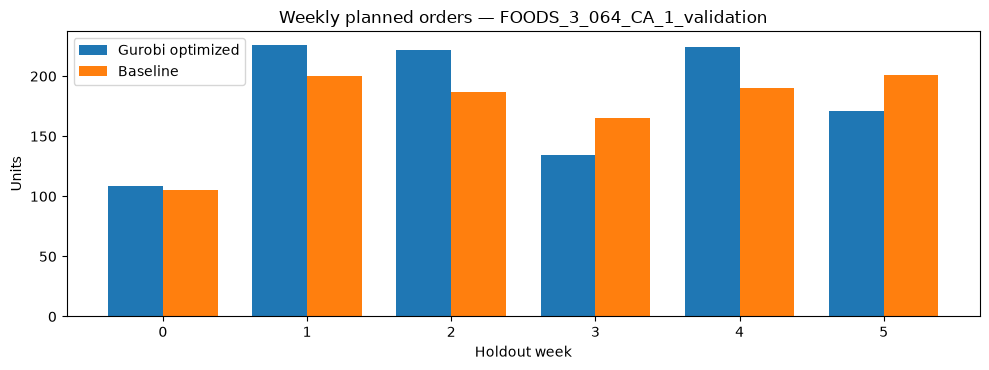

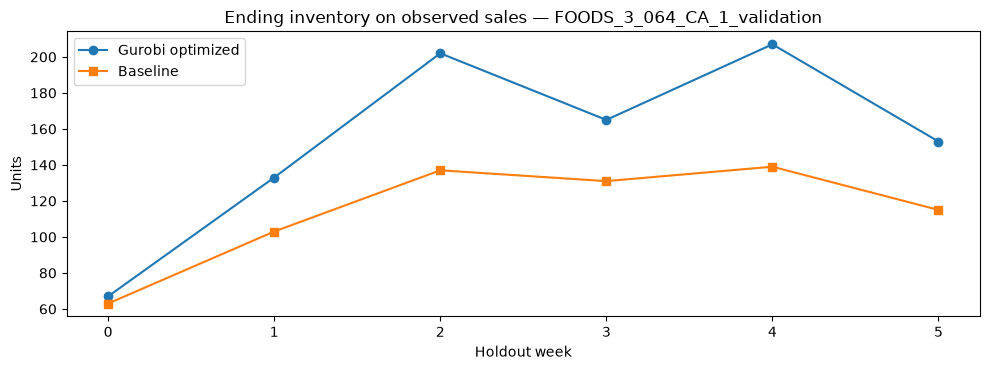

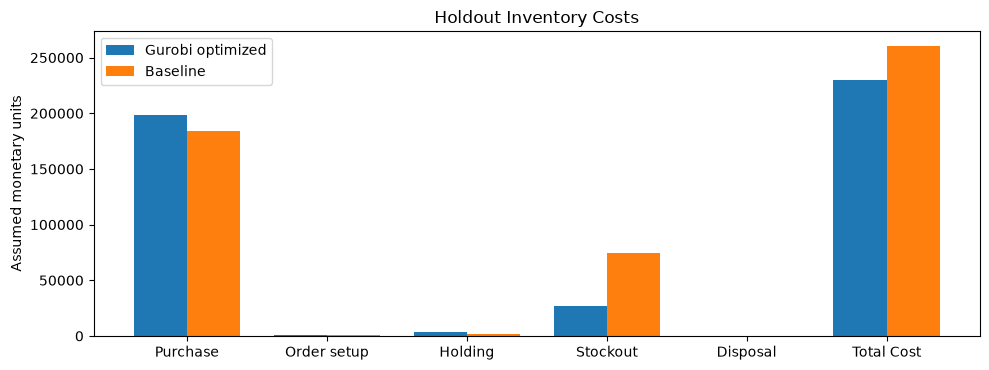

In [15]:
selected_sku = I[0]
per_sku_orders = gurobi_plan.query('sku == @selected_sku').sort_values('week')
per_sku_inventory = gurobi_inventory_trajectory.loc[gurobi_inventory_trajectory['sku'] == selected_sku].sort_values('week')
baseline_sku_orders = baseline_plan.query('sku == @selected_sku').sort_values('week')
baseline_sku_inventory = baseline_inventory_trajectory.query('sku == @selected_sku').sort_values('week')
bar_width = 0.38
plt.figure(figsize=(10, 3.8))
plt.bar(per_sku_orders['week'].to_numpy() - bar_width/2,
        per_sku_orders['order_qty'], width=bar_width, label='Gurobi optimized')
plt.bar(baseline_sku_orders['week'].to_numpy() + bar_width/2,
        baseline_sku_orders['order_qty'], width=bar_width, label='Baseline')
plt.title(f'Weekly planned orders — {selected_sku}')
plt.xlabel('Holdout week'); plt.ylabel('Units'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3.8))
plt.plot(per_sku_inventory['week'], per_sku_inventory['ending_inventory'], marker='o',label='Gurobi optimized')
plt.plot(baseline_sku_inventory['week'], baseline_sku_inventory['ending_inventory'], marker='s',label='Baseline')
plt.title(f'Ending inventory on observed sales — {selected_sku}')
plt.xlabel('Holdout week'); plt.ylabel('Units'); plt.legend(); plt.tight_layout(); plt.show()


labels = ['Purchase', 'Order setup', 'Holding', 'Stockout', 'Disposal', 'Total Cost']

base_values = [baseline_holdout_metrics[k] for k in COST_COMPONENTS] + [baseline_holdout_metrics['cost']]
opt_values = [gurobi_holdout_metrics[k] for k in COST_COMPONENTS] + [gurobi_holdout_metrics['cost']]

xx = np.arange(len(labels))
plt.figure(figsize=(10, 3.8))
plt.bar(xx - 0.19, opt_values, width=0.38, label='Gurobi optimized')
plt.bar(xx + 0.19, base_values, width=0.38, label='Baseline')
plt.xticks(xx, labels)
plt.ylabel('Assumed monetary units'); plt.title('Holdout Inventory Costs')
plt.legend(); plt.tight_layout(); plt.show()

## Save the evaluation

In [16]:
(RESULTS_DIR/'holdout_metrics_gurobi.json').write_text(
    json.dumps(gurobi_holdout_metrics, indent=2) + '\n', encoding='utf-8'
)
gurobi_scenario_details.to_csv(RESULTS_DIR/'holdout_scenario_gurobi.csv', index=False)
gurobi_inventory_trajectory.to_csv(RESULTS_DIR/'inventory_trajectory_gurobi.csv', index=False)
order_schedule.to_csv(RESULTS_DIR/'order_schedule_gurobi.csv')
print('Saved Gurobi-only outputs in:', RESULTS_DIR)
print('  orders_gurobi.csv')
print('  solver_gurobi.json')
print('  holdout_metrics_gurobi.json')
print('  inventory_trajectory_gurobi.csv')
print('  order_schedule_gurobi.csv')
# Save baseline-versus-optimized results for THIS solver only.
baseline_plan.to_csv(RESULTS_DIR/'baseline_orders.csv', index=False)
baseline_inventory_trajectory.to_csv(RESULTS_DIR/'baseline_inventory_trajectory.csv', index=False)
policy_comparison.to_csv(RESULTS_DIR/'holdout_comparison_gurobi.csv', index=False)
(RESULTS_DIR/'baseline_holdout_metrics.json').write_text(
    json.dumps(baseline_holdout_metrics, indent=2) + '\n', encoding='utf-8'
)
print('Saved baseline and Gurobi-only policy comparison outputs.')


Saved Gurobi-only outputs in: /Users/zodii/Documents/Projects/Inventory_Optimization/results
  orders_gurobi.csv
  solver_gurobi.json
  holdout_metrics_gurobi.json
  inventory_trajectory_gurobi.csv
  order_schedule_gurobi.csv
Saved baseline and Gurobi-only policy comparison outputs.
